In [ ]:
from io import StringIO
import numpy as np
from phylomodel_models import ParentPredictor
from dataset_prep_aux_fns import *
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
import torch.nn as nn
import pickle as pkl

from tqdm import tqdm


def greedy_phylo_tree_bottom_up(P):

    n = P.shape[0]
    A = np.zeros((n, n), dtype=int)

    P[0,:] = 0.0
    
    root = 0
    parents = {root: None}
    parent_count = {}
    assigned_children = {root: []}

    n_int_nodes = P.shape[1]
    leaf_nodes = list(range(n_int_nodes, n))

    used = set(leaf_nodes)

    assert (np.tril(P, k = -1) == P).all()

    for u in range(1, n):

        probs = [(float(P[u, v]), v) for v in range(n_int_nodes) if v not in used and P[u,v] > 0]
        probs.sort(reverse=True)

        parent_candidate = probs[0][1]

        if parent_candidate not in parent_count.keys():
            parent_count[parent_candidate] = 1
            parents[u] = parent_candidate
            assigned_children[parent_candidate] = [u]
            A[u, parent_candidate] = 1
        
        elif parent_count[parent_candidate] < 2:
            parent_count[parent_candidate] += 1
            parents[u] = parent_candidate
            assigned_children[parent_candidate].append(u)
            used.add(parent_candidate)
            A[u, parent_candidate] = 1
        
    return A

def will_create_cycle(adj, u, v):

    n = adj.shape[0]

    # DFS starting from v to see if we can reach u
    visited = set()
    stack = [v]

    while stack:
        node = stack.pop()
        if node == u:
            return True  # cycle detected
        if node not in visited:
            visited.add(node)
            neighbors = np.where(adj[:, node] != 0)[0]  # outgoing edges
            stack.extend(neighbors)

    return False


def prepare_initial_leaf_embeddings(msa, Large_D = 1000, model = None, batch_converter = None, device = None):

    torch.cuda.empty_cache()

    _, _, tokens = batch_converter([msa])
    tokens = tokens.to(device)

    with torch.no_grad():
        embeddings = model(tokens, need_head_weights = False, return_contacts = False, repr_layers = [12])["representations"][12][0]
        embeddings = embeddings.mean(dim=1)
        R, H = embeddings.shape
        padding_tensor = torch.zeros((R, Large_D - H)).to(device)
        embeddings = torch.concat((embeddings, padding_tensor), dim=1)

        del padding_tensor, tokens
        torch.cuda.empty_cache()

    return embeddings

def to_newick(G, node):
    children = list(G.successors(node))  # for directed graph
    if not children:
        # Leaf: just return name with branch length if available
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"{node}:{G[parent][node].get('weight', 1.0)}"
        else:
            return node  # root leaf (edge case)
    else:
        # Internal node: recurse over children
        subtrees = [to_newick(G, c) for c in children]
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"({','.join(subtrees)}){node}:{G[parent][node].get('weight', 1.0)}"
        else:
            # Root node (no incoming edge) → no branch length
            return f"({','.join(subtrees)}){node}"

gpu = str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"

checkpoint_path = "../models/fit-PF00004-size-4-50-epochs.pt"

checkpoint = torch.load(checkpoint_path, weights_only=True)

model = ParentPredictor(**checkpoint["model_hparams"]).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

gpu = str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
msa_transf, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transf = msa_transf.to(device)
batch_converter = alphabet.get_batch_converter()
msa_transf.eval()

with open("../data/families_under_200_over_50.pkl","rb") as f:

    all_families_init = pkl.load(f)

all_families = []

for family in all_families_init:

    if os.path.exists(f"../data/msa-seed-simulations/MSA-1b/{family}/init-seq-0/logits-proposal/static-context/10/{family}-1.fasta"):
        all_families.append(family)


np.random.seed(42)

data_ids = list(range(1,20000))

train_split = 0.9
train_size = int(np.ceil(train_split * len(data_ids)))

train_ids_ind = np.random.choice(range(len(data_ids)), train_size, replace = False)
train_ids = [data_ids[ind] for ind in train_ids_ind]

test_ids_ind = list(set(range(len(data_ids))) - set(train_ids_ind))
test_ids = [data_ids[ind] for ind in test_ids_ind]

# all_families = all_families[:100]

inferred_trees = {}

for data_id in tqdm(test_ids):

    input_MSA_path = f"../data/submsa-seed-simulations-equal-size/4/PF00004/submsa-{data_id}.fasta"
    input_MSA = read_msa(input_MSA_path)

    n_int_nodes = len(input_MSA) - 1
    total_nodes = 2 * len(input_MSA) - 1
    leaf_nodes = len(input_MSA)


    input_MSA_order = {seq[0]:i for i,seq in enumerate(input_MSA)}

    leaf_embeddings = prepare_initial_leaf_embeddings(input_MSA, Large_D=768, model= msa_transf, batch_converter= batch_converter, device = device)

    int_node_embeddings = prepare_initial_int_node_embeddings(input_MSA_path, input_MSA_order, Large_D=768, leaf_embeddings=leaf_embeddings, delete_init_tree = False, fam = family)

    X = torch.concat((int_node_embeddings, leaf_embeddings), dim=0)

    with torch.no_grad():
        soft_adj_mat = model(X, attn_mask = None).squeeze(-1)[...,:n_int_nodes]
        size = soft_adj_mat.shape[0]
        mask = torch.triu(torch.ones(size, size), diagonal=0).bool()[...,:n_int_nodes].to(device)
        soft_adj_mat = soft_adj_mat.masked_fill(mask, float('-inf'))
        soft_adj_mat = nn.Softmax(dim = 1)(soft_adj_mat).cpu().numpy()

    hard_adj_mat = greedy_phylo_tree_bottom_up(soft_adj_mat)
    hard_adj_mat = np.transpose(hard_adj_mat)

    tree_graph = nx.from_numpy_array(hard_adj_mat, create_using=nx.DiGraph)

    labels = list(map(str,range(n_int_nodes))) + list(input_MSA_order.keys())
    mapping = {i: labels[i] for i in range(len(labels))}
    tree_graph = nx.relabel_nodes(tree_graph, mapping)

    newick_str = to_newick(tree_graph, "0") + ";"
    tree = Tree(newick=newick_str, format = 1)
    inferred_trees[data_id] = tree

100%|██████████| 1/1 [00:06<00:00,  6.16s/it]


In [11]:
from ete3 import Tree

init_tree = Tree("./PF00005-init-tree.newick", format=1)
init_tree.set_outgroup(init_tree.get_midpoint_outgroup())

inferred_tree = Tree("./PF00005-inferred-tree.newick", format = 1)

true_tree = Tree("../data/seed-trees/PF00005_seed.newick", format = 1)
true_tree.set_outgroup(true_tree.get_midpoint_outgroup())


In [ ]:
from ete3 import Tree

tree_rfs = []

for id in tqdm(test_ids):

    MSA_file_path = f"../data/submsa-seed-simulations-equal-size/4/PF00004/submsa-{id}.fasta"

    temp_tree_file = f"{MSA_file_path}-temp.newick"

    subprocess.run(["rapidnj",MSA_file_path,"-i","fa","-x",temp_tree_file])

    init_tree = Tree(temp_tree_file, format=1)
    init_tree.set_outgroup(init_tree.get_midpoint_outgroup())

    for node in init_tree.get_leaves():
        node.name = node.name.replace("'","")
    
    subprocess.run(['rm', temp_tree_file])

    inferred_tree = inferred_trees[id]

    true_tree = Tree(f"../data/msa-seed-simulations-subtrees-equal-size/4/PF00004/subtree-{id}.newick", format = 1)
    true_tree.set_outgroup(true_tree.get_midpoint_outgroup())

    tree_rfs.append({"subtree_id":id,
                     "inferred-true-rf": inferred_tree.compare(true_tree)["norm_rf"],
                    "inferred-init-rf": inferred_tree.compare(init_tree)["norm_rf"],
                    "init-true-rf": init_tree.compare(true_tree)["norm_rf"]
                    })

tree_rfs = pd.DataFrame(tree_rfs)

## Root Distance and Branch Length Method

In [31]:
from io import StringIO
import numpy as np
from phylomodel_models_root_distance import MainPhyloModel
from dataset_prep_aux_fns import *
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
import torch.nn as nn
import pickle as pkl

from tqdm import tqdm

def adj_mat_from_distances(branch_lengths, root_distances):

    n_nodes = len(branch_lengths)
    n_int_nodes = int((len(branch_lengths) + 1)/2 - 1)
    n_leaf_nodes = n_int_nodes + 1

    A = np.zeros((n_nodes, n_nodes))

    queue = [0]
    used = set([0])

    total_leaf_count = 0

    while queue:

        cur_node = queue.pop(0)

        if cur_node > n_int_nodes - 1:
            continue

        diff =  root_distances - branch_lengths - root_distances[cur_node]
        diff_ind_order = np.argsort(diff)

        n_children = 0
        leaf_children = 0

        for i in diff_ind_order:

            if len(queue) == 1 and leaf_children == 1 and i > n_int_nodes - 1 and total_leaf_count < n_leaf_nodes - 1:
                continue

            if n_children == 2:
                break
            
            if i not in used:

                A[cur_node, i] = branch_lengths[i]
                queue.append(i)
                used.add(i)
                n_children += 1

                if i > n_int_nodes - 1:
                    leaf_children += 1
                    total_leaf_count += 1

    return A

def prepare_initial_leaf_embeddings(msa, Large_D = 1000, model = None, batch_converter = None, device = None):

    torch.cuda.empty_cache()

    _, _, tokens = batch_converter([msa])
    tokens = tokens.to(device)

    with torch.no_grad():
        embeddings = model(tokens, need_head_weights = False, return_contacts = False, repr_layers = [12])["representations"][12][0]
        embeddings = embeddings.mean(dim=1)
        R, H = embeddings.shape
        padding_tensor = torch.zeros((R, Large_D - H)).to(device)
        embeddings = torch.concat((embeddings, padding_tensor), dim=1)

        del padding_tensor, tokens
        torch.cuda.empty_cache()

    return embeddings

def to_newick(G, node):
    children = list(G.successors(node))  # for directed graph
    if not children:
        # Leaf: just return name with branch length if available
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"{node}:{G[parent][node].get('weight', 1.0)}"
        else:
            return node  # root leaf (edge case)
    else:
        # Internal node: recurse over children
        subtrees = [to_newick(G, c) for c in children]
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"({','.join(subtrees)}){node}:{G[parent][node].get('weight', 1.0)}"
        else:
            # Root node (no incoming edge) → no branch length
            return f"({','.join(subtrees)}){node}"

gpu = str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
msa_transf, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transf = msa_transf.to(device)
batch_converter = alphabet.get_batch_converter()
msa_transf.eval()

checkpoint_path = "../models/fit-PF00004-size-50-weighted-50-epochs.pt"

checkpoint = torch.load(checkpoint_path, weights_only=False)

model = MainPhyloModel(**checkpoint["model_hparams"]).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with open("../data/families_under_200_over_10.pkl","rb") as f:

    all_families_init = pkl.load(f)

all_families = []

for family in all_families_init:

    if os.path.exists(f"../data/msa-seed-simulations/MSA-1b/{family}/init-seq-0/logits-proposal/static-context/10/{family}-1.fasta"):
        all_families.append(family)

# all_families = all_families[:1]

np.random.seed(42)

data_ids = list(range(1,20000))

train_split = 0.9
train_size = int(np.ceil(train_split * len(data_ids)))

train_ids_ind = np.random.choice(range(len(data_ids)), train_size, replace = False)
train_ids = [data_ids[ind] for ind in train_ids_ind]

test_ids_ind = list(set(range(len(data_ids))) - set(train_ids_ind))
test_ids = [data_ids[ind] for ind in test_ids_ind]

# all_families = all_families[:100]

inferred_trees = {}
# train_ids= ["4745"]

for id in tqdm(test_ids):

    input_MSA_path = f"../data/submsa-seed-simulations-equal-size/50/PF00004/submsa-{id}.fasta"
    input_MSA = read_msa(input_MSA_path)

    n_int_nodes = len(input_MSA) - 1
    total_nodes = 2 * len(input_MSA) - 1
    leaf_nodes = len(input_MSA)

    input_MSA_order = {seq[0]:i for i,seq in enumerate(input_MSA)}
    X = prepare_initial_leaf_embeddings(input_MSA, Large_D=768, model = msa_transf, batch_converter = batch_converter, device = device)

    with torch.no_grad():
        branch_lengths, root_distances = model(X, attn_mask = None)
        branch_lengths = branch_lengths.squeeze(-1).cpu().numpy()
        root_distances = root_distances.squeeze(-1).cpu().numpy()

    hard_adj_mat = adj_mat_from_distances(branch_lengths, root_distances)
    tree_graph = nx.from_numpy_array(hard_adj_mat, create_using=nx.DiGraph)

    labels = list(map(str,range(n_int_nodes))) + list(input_MSA_order.keys())
    mapping = {i: labels[i] for i in range(len(labels))}
    tree_graph = nx.relabel_nodes(tree_graph, mapping)

    # cycles = list(nx.simple_cycles(tree_graph))
    # print("Cycles found:", cycles)

    # cycle_nodes = set(n for c in cycles for n in c)
    # node_colors = ["red" if n in cycle_nodes else "lightblue" for n in tree_graph.nodes]

    # pos = graphviz_layout(tree_graph, prog="dot")
    # plt.figure(figsize=(30, 30))
    # nx.draw(tree_graph, pos,
    #         with_labels=True,
    #         node_color=node_colors,
    #         node_size=500,
    #         arrowsize=20,
    #         font_size=8)

    # plt.title("Cycles highlighted in red")
    # plt.show()

    # newick_str = to_newick(tree_graph, "0") + ";"

    # handle = StringIO(newick_str)
    # tree = Phylo.read(handle, "newick")
    # Phylo.write(tree, "inferred-tree-test.newick", "newick")
    # Phylo.draw_ascii(tree)
    
    newick_str = to_newick(tree_graph, "0") + ";"
    tree = Tree(newick=newick_str, format = 1)
    inferred_trees[id] = tree




    

100%|██████████| 1999/1999 [05:01<00:00,  6.63it/s]


In [32]:
from ete3 import Tree

tree_rfs = []

for id in tqdm(test_ids):

    MSA_file_path = f"../data/submsa-seed-simulations-equal-size/50/PF00004/submsa-{id}.fasta"

    temp_tree_file = f"{MSA_file_path}-temp.newick"

    subprocess.run(["rapidnj",MSA_file_path,"-i","fa","-x",temp_tree_file])

    init_tree = Tree(temp_tree_file, format=1)
    init_tree.set_outgroup(init_tree.get_midpoint_outgroup())

    for node in init_tree.get_leaves():
        node.name = node.name.replace("'","")
    
    subprocess.run(['rm', temp_tree_file])

    inferred_tree = inferred_trees[id]

    true_tree = Tree(f"../data/msa-seed-simulations-subtrees-equal-size/50/PF00004/subtree-{id}.newick", format = 1)
    true_tree.set_outgroup(true_tree.get_midpoint_outgroup())

    tree_rfs.append({"subtree_id":id,
                     "inferred-true-rf": inferred_tree.compare(true_tree)["norm_rf"],
                    "inferred-init-rf": inferred_tree.compare(init_tree)["norm_rf"],
                    "init-true-rf": init_tree.compare(true_tree)["norm_rf"]
                    })

tree_rfs = pd.DataFrame(tree_rfs)

100%|██████████| 1999/1999 [00:36<00:00, 54.47it/s]0% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00

In [34]:
tree_rfs["inferred-true-rf"].mean()

np.float64(0.9141990844935171)

In [22]:
import pickle as pkl

with open("../data/processed-train-test-data/root_distance_MSA_train_test_sets_PF00004_size_50.pkl","rb") as f:
   data = pkl.load(f)

X_train = data[0]
X_test = data[1]
y_train_bl = data[2]
y_test_bl = data[3]
y_train_rd = data[4]
y_test_rd = data[5]

In [23]:
import matplotlib.pyplot as plt

bl_rd_ratio_means = [(y_train_bl[i][1:].numpy()/y_train_rd[i][1:].numpy()).mean() for i in range(len(y_train_bl))]


(array([6.000e+00, 7.000e+00, 8.000e+00, 6.000e+00, 6.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 2.000e+00,
        3.000e+00, 4.000e+00, 9.000e+00, 1.300e+01, 3.300e+01, 7.500e+01,
        1.650e+02, 1.750e+02, 2.440e+02, 2.430e+02, 2.370e+02, 2.380e+02,
        2.960e+02, 3.440e+02, 6.020e+02, 8.360e+02, 1.113e+03, 1.412e+03,
        1.515e+03, 1.531e+03, 1.397e+03, 1.220e+03, 1.054e+03, 9.440e+02,
        8.550e+02, 8.430e+02, 7.030e+02, 5.210e+02, 4.730e+02, 3.340e+02,
        2.220e+02, 1.480e+02, 8.400e+01, 4.300e+01, 1.200e+01, 6.000e+00,
        4.000e+00, 2.000e+00]),
 array([0.12353197, 0.1285913 , 0.13365063, 0.13870996, 0.14376929,
        0.14882863, 0.15388794, 0.15894727, 0.16400661, 0.16906594,
        0.17412525, 0.17918459, 0.18424392, 0.18930325, 0.19436258,
        0.19942191, 0.20448124, 0.20954058, 0.21459989, 0.21965922,
        0.22471854, 0.22977787, 0.2348372 , 0.23989654, 0.24495587,
        0.2500152 , 0.25507453, 0.26

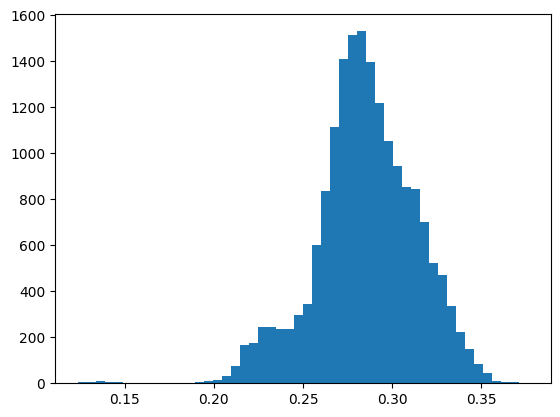

In [24]:
plt.hist(bl_rd_ratio_means, bins=50)

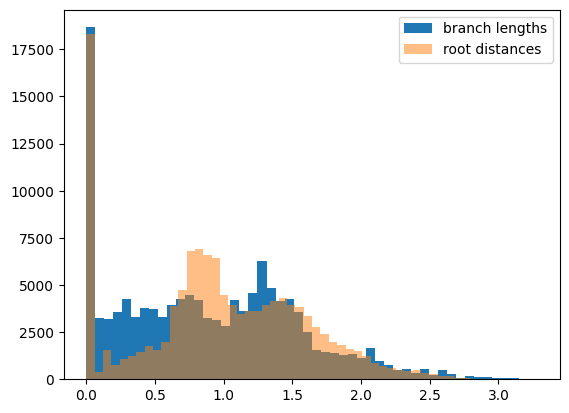

In [35]:
import numpy as np
import torch

fig, axes  = plt.subplots()

axes.hist(torch.concat(y_train_bl).numpy(), label = "branch lengths", bins = 50,)
axes.hist(torch.concat(y_train_rd).numpy() * 0.6, label = "root distances", bins = 50, alpha = 0.5)
plt.legend()